In [ ]:
# === Imports (all external dependencies) ===
import os, sys
# This notebook now lives 1 folder deep (eda/), so '..' reaches the repo root.
sys.path.insert(0, os.path.abspath('..'))

import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import spearmanr
from esda.moran import Moran
from libpysal.weights import KNN

import col_amazon_fire_utils as utils

ee = utils.initialize_ee()
nucleus_geom = utils.get_nucleus_geometry()

# MapBiomas (for mosaic distance)
mb_lulc = ee.Image('projects/mapbiomas-colombia/assets/LULC/COLECCION3/INTEGRACION/COLOMBIA-1')
from_codes = [3, 6, 5,   4, 11, 12, 13,   15,   18, 35,   21,   33,   9, 23, 24, 29, 30, 68]
to_groups  = [1, 1, 1,   2,  2,  2,  2,    3,    4,  4,    5,    6,    7,  7,  7,  7,  7,  7]

base = 'projects/col-amazon-fire-susceptibility/assets/'
layers = {
    'parks': ee.FeatureCollection(base + 'national_natural_parks'),
    'roads': ee.FeatureCollection(base + 'osm_roads_v2'),
    'coca':  ee.FeatureCollection(base + 'coca_cultivation_v2'),
}

# ONI (DJF, NOAA CPC) — spatially constant per year
oni_djf = {2001:-0.7,2002:-0.1,2003:0.9,2004:0.4,2005:0.6,2006:-0.9,2007:0.7,
           2008:-1.6,2009:-0.8,2010:1.5,2011:-1.3,2012:-0.7,2013:-0.3,2014:-0.3,
           2015:0.7,2016:2.6,2017:-0.2,2018:-0.8,2019:0.9,2020:0.6,2021:-0.9,
           2022:-0.8,2023:-0.5,2024:1.9}
print("Setup ready.")

Setup ready.


In [8]:
# === Distance predictors ===
SEARCH_RADIUS = 10000
buf = nucleus_geom.buffer(SEARCH_RADIUS)

dist_roads = layers['roads'].filterBounds(buf).distance(SEARCH_RADIUS).rename('dist_roads')
dist_parks = layers['parks'].filterBounds(nucleus_geom.buffer(100000)).distance(100000).rename('dist_parks')

def coca_ever(f):
    total = ee.List([ee.Number(f.get(f'coca_{y}')) for y in range(2001,2024)]).reduce(ee.Reducer.sum())
    return f.set('coca_total', total)
coca_any = layers['coca'].filterBounds(buf).map(coca_ever).filter(ee.Filter.gt('coca_total',0))
dist_coca = coca_any.distance(SEARCH_RADIUS).rename('dist_coca')

mosaic_mask = mb_lulc.select('classification_2024').clip(buf).remap(from_codes,to_groups,0).eq(5)
dist_mosaic = (mosaic_mask.selfMask().fastDistanceTransform().sqrt()
               .multiply(ee.Image.pixelArea().sqrt()).rename('dist_mosaic'))

dist_stack = dist_roads.addBands(dist_parks).addBands(dist_coca).addBands(dist_mosaic)

# === Climate: average dry-season image (pixel-varying), for the diagnostic sample ===
def dry_season_climate(y0=2001, y1=2024):
    def one_year(year):
        year = ee.Number(year)
        start = ee.Date.fromYMD(year.subtract(1),12,1); end = ee.Date.fromYMD(year,3,1)
        era5 = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR').filterDate(start,end)
        def derive(img):
            u=img.select('u_component_of_wind_10m'); v=img.select('v_component_of_wind_10m')
            wind=u.hypot(v).rename('wind_ms')
            t=img.select('temperature_2m').subtract(273.15)
            td=img.select('dewpoint_temperature_2m').subtract(273.15)
            es=t.expression('0.6108*exp(17.27*T/(T+237.3))',{'T':t})
            e=td.expression('0.6108*exp(17.27*Td/(Td+237.3))',{'Td':td})
            return img.addBands([wind, e.divide(es).multiply(100).rename('rh_pct'),
                                 es.subtract(e).rename('vpd_kPa')])
        era5=era5.map(derive)
        temp=era5.select('temperature_2m').mean().subtract(273.15).rename('temp_C')
        precip=era5.select('total_precipitation_sum').sum().multiply(1000).rename('precip_mm')
        ndvi=(ee.ImageCollection('MODIS/061/MOD13A1').filterDate(start,end)
              .select('NDVI').mean().multiply(0.0001).rename('ndvi'))
        return temp.addBands([precip, era5.select('wind_ms').mean(),
                              era5.select('rh_pct').mean(), era5.select('vpd_kPa').mean(), ndvi])
    return ee.ImageCollection(ee.List.sequence(y0,y1).map(one_year)).mean()

climate_stack = dry_season_climate()
burned_ever = (ee.ImageCollection('MODIS/061/MCD64A1').filterDate('2001-01-01','2025-12-31')
               .select('BurnDate').map(lambda i:i.gt(0)).max().unmask(0).rename('burned'))

full_stack = dist_stack.addBands(climate_stack).addBands(burned_ever).clip(nucleus_geom)

# === Sample (the imbalanced 3000, for diagnostics only) ===
def fc_to_df_xy(fc):
    feats = fc.getInfo()['features']
    rows=[]
    for f in feats:
        r=dict(f['properties']); r['lon'],r['lat']=f['geometry']['coordinates']; rows.append(r)
    return pd.DataFrame(rows)

samples = full_stack.sample(region=nucleus_geom, scale=500, numPixels=3000, seed=42, geometries=True)
df = fc_to_df_xy(samples).dropna()
print("Sample shape:", df.shape, "| burned:", int(df['burned'].sum()))

Sample shape: (1293, 13) | burned: 395


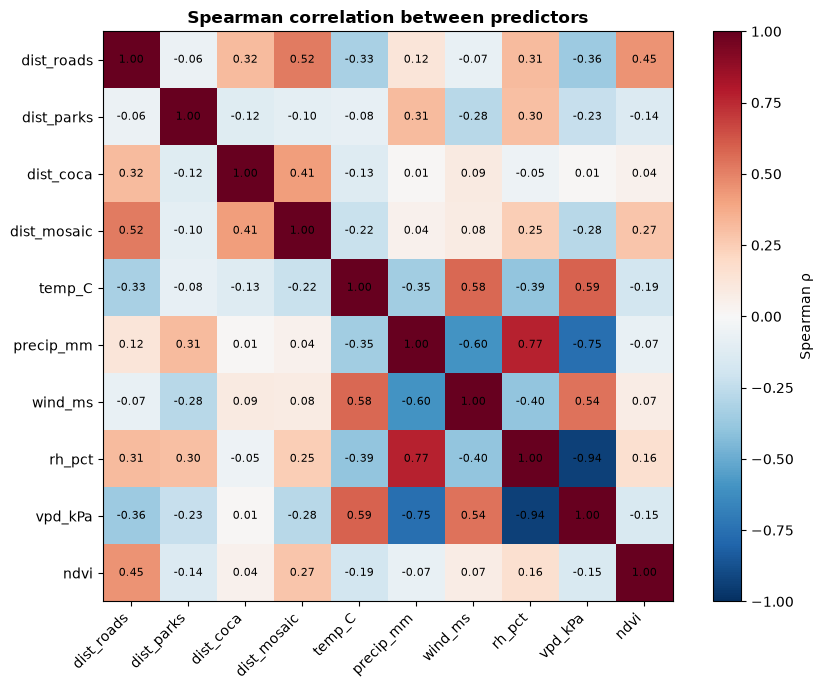

Strong pairs (|ρ| > 0.7):
  precip_mm ↔ rh_pct: +0.77
  precip_mm ↔ vpd_kPa: -0.75
  rh_pct ↔ vpd_kPa: -0.94


In [ ]:
pred_cols = ['dist_roads','dist_parks','dist_coca','dist_mosaic',
             'temp_C','precip_mm','wind_ms','rh_pct','vpd_kPa','ndvi']
X = df[pred_cols]

rho, _ = spearmanr(X)
rho_df = pd.DataFrame(rho, index=pred_cols, columns=pred_cols)

plt.figure(figsize=(9,7))
plt.imshow(rho_df, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label="Spearman ρ")
plt.xticks(range(len(pred_cols)), pred_cols, rotation=45, ha='right')
plt.yticks(range(len(pred_cols)), pred_cols)
for i in range(len(pred_cols)):
    for j in range(len(pred_cols)):
        plt.text(j, i, f"{rho_df.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.title("Spearman correlation between predictors", fontweight='bold')
plt.tight_layout(); plt.savefig('../outputs/diagnostics/spearman.png', dpi=150, bbox_inches='tight'); plt.show()

# Flag strong pairs (|rho| > 0.7)
print("Strong pairs (|ρ| > 0.7):")
for i in range(len(pred_cols)):
    for j in range(i+1, len(pred_cols)):
        if abs(rho_df.iloc[i,j]) > 0.7:
            print(f"  {pred_cols[i]} ↔ {pred_cols[j]}: {rho_df.iloc[i,j]:+.2f}")

In [11]:
# === Variance Inflation Factor (VIF) ===
Xv = X.dropna().values
vif = pd.DataFrame({
    'predictor': pred_cols,
    'VIF': [variance_inflation_factor(Xv, i) for i in range(len(pred_cols))]
}).sort_values('VIF', ascending=False)
print("VIF (multicollinearity — >5 suspect, >10 serious):")
print(vif.round(2).to_string(index=False))

VIF (multicollinearity — >5 suspect, >10 serious):
  predictor    VIF
     temp_C 929.44
     rh_pct 612.58
       ndvi 131.51
    vpd_kPa 112.17
  precip_mm  42.48
    wind_ms  27.64
 dist_roads   4.14
 dist_parks   3.75
dist_mosaic   2.72
  dist_coca   2.53


In [ ]:
# === Moran's I on the target: is fire spatially clustered? ===
coords = df[['lon','lat']].values
y = df['burned'].astype(int).values

# Spatial weights: each point linked to its k nearest neighbours
w = KNN.from_array(coords, k=8) # 8 nearest neighbours
w.transform = 'r'

mi = Moran(y, w)
print(f"Moran's I : {mi.I:.3f}")
print(f"p-value   : {mi.p_sim:.4f}")
print(f"→ {'Significant spatial clustering' if mi.p_sim < 0.05 else 'No significant clustering'}")

# Estimate the autocorrelation RANGE via a correlogram (Moran's I at increasing distances)
from libpysal.weights import DistanceBand
print("\nMoran's I by distance band (to find the range):")
for d in [1000, 2000, 3000, 5000, 7500, 10000, 15000]:   # metres — approx, coords in degrees
    d_deg = d / 111000                                    # rough deg-per-metre at the equator
    try:
        wd = DistanceBand.from_array(coords, threshold=d_deg, binary=True, silence_warnings=True)
        wd.transform = 'r'
        m_d = Moran(y, wd)
        print(f"  {d/1000:>5.1f} km : I={m_d.I:+.3f}  (p={m_d.p_sim:.3f})")
    except Exception as e:
        print(f"  {d/1000:>5.1f} km : skipped ({type(e).__name__})")

c:\Users\Natal\.conda\envs\fire_thesis\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Moran's I : 0.329
p-value   : 0.0010
→ Significant spatial clustering

Moran's I by distance band (to find the range):
    1.0 km : I=+0.460  (p=0.001)
    2.0 km : I=+0.459  (p=0.001)
    3.0 km : I=+0.407  (p=0.001)
    5.0 km : I=+0.419  (p=0.001)
    7.5 km : I=+0.354  (p=0.001)
   10.0 km : I=+0.332  (p=0.001)
   15.0 km : I=+0.324  (p=0.001)


In [13]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Candidate reduced set: drop the redundant humidity twins (rh_pct, precip_mm)
reduced_cols = ['dist_roads','dist_parks','dist_coca','dist_mosaic',
                'temp_C','vpd_kPa','ndvi','wind_ms']

# Standardize so VIF is interpretable, and add an intercept
Xr = StandardScaler().fit_transform(df[reduced_cols].dropna())
Xr = sm.add_constant(Xr)                      # VIF needs an intercept column

vif_reduced = pd.DataFrame({
    'predictor': ['const'] + reduced_cols,
    'VIF': [variance_inflation_factor(Xr, i) for i in range(Xr.shape[1])]
})
print(vif_reduced[vif_reduced['predictor'] != 'const'].round(2).to_string(index=False))

  predictor  VIF
 dist_roads 2.03
 dist_parks 1.34
  dist_coca 1.62
dist_mosaic 2.03
     temp_C 1.58
    vpd_kPa 1.84
       ndvi 1.22
    wind_ms 1.79
